# EDA for Fires.csv with polars

In [1]:
from pathlib import Path

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pl.read_csv("data/FiresRu.csv")

df.head()

type_name,type_id,lon,lat,temperature_c,precipitation_mm,relative_humidity,wind_speed_ms,solar_radiation
str,i64,f64,f64,f64,f64,f64,f64,f64
"""Natural fire""",4,131.5866,47.8662,-9.44,0.01,72.98,1.14,4.59
"""Natural fire""",4,131.5885,47.8809,-9.44,0.01,72.98,1.14,4.59
"""Forest fire""",3,131.9871,48.4973,-10.71,0.05,81.31,0.8,4.24
"""Natural fire""",4,131.9031,43.6277,-7.77,0.0,68.41,0.97,4.66
"""Natural fire""",4,131.5706,47.8581,-9.44,0.01,72.98,1.14,4.59


In [3]:
df.describe()

statistic,type_name,type_id,lon,lat,temperature_c,precipitation_mm,relative_humidity,wind_speed_ms,solar_radiation
str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""26681""",26681.0,26681.0,26681.0,26681.0,26681.0,26681.0,26681.0,26681.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,3.015442,106.347438,57.525623,17.887258,0.45789,69.443731,0.63064,5.57262
"""std""",null,0.807379,27.31253,4.295205,5.681052,1.458436,11.432802,0.925136,1.503567
"""min""","""Controlled burn""",1.0,20.372,41.7062,-34.88,0.0,24.7,0.0,0.42
"""25%""",null,3.0,82.4135,53.9481,15.7,0.0,62.93,0.11,4.55
"""50%""",null,3.0,96.5555,58.9685,19.08,0.04,71.35,0.25,5.68
"""75%""",null,3.0,133.8976,60.6386,21.39,0.3,77.91,0.66,6.71
"""max""","""Uncontrolled burn""",5.0,175.8692,70.3334,31.94,25.85,99.83,7.42,8.97


In [4]:
df.glimpse()

Rows: 26681
Columns: 9
$ type_name         <str> 'Natural fire', 'Natural fire', 'Forest fire', 'Natural fire', 'Natural fire', 'Natural fire', 'Natural fire', 'Natural fire', 'Natural fire', 'Controlled burn'
$ type_id           <i64> 4, 4, 3, 4, 4, 4, 4, 4, 4, 5
$ lon               <f64> 131.5866, 131.5885, 131.9871, 131.9031, 131.5706, 131.5798, 20.4452, 125.8202, 38.2039, 39.0129
$ lat               <f64> 47.8662, 47.8809, 48.4973, 43.6277, 47.8581, 52.1321, 54.8597, 55.209, 45.5618, 44.9598
$ temperature_c     <f64> -9.44, -9.44, -10.71, -7.77, -9.44, -14.91, 1.51, -23.0, 7.35, 5.84
$ precipitation_mm  <f64> 0.01, 0.01, 0.05, 0.0, 0.01, 1.9, 0.49, 0.06, 0.0, 0.0
$ relative_humidity <f64> 72.98, 72.98, 81.31, 68.41, 72.98, 97.41, 93.98, 96.21, 73.51, 75.6
$ wind_speed_ms     <f64> 1.14, 1.14, 0.8, 0.97, 1.14, 1.06, 4.05, 2.31, 6.64, 6.03
$ solar_radiation   <f64> 4.59, 4.59, 4.24, 4.66, 4.59, 4.3, 2.53, 4.37, 5.19, 5.21



In [5]:
df.select(pl.all().n_unique())

type_name,type_id,lon,lat,temperature_c,precipitation_mm,relative_humidity,wind_speed_ms,solar_radiation
u32,u32,u32,u32,u32,u32,u32,u32,u32
5,5,25708,23547,2581,571,4028,532,731


In [6]:
df.is_duplicated().sum()

0

In [7]:
df.select(pl.col(["type_id", "type_name"])).unique().sort(by=pl.col("type_id"))

type_id,type_name
i64,str
1,"""Uncontrolled burn"""
2,"""Peat fire"""
3,"""Forest fire"""
4,"""Natural fire"""
5,"""Controlled burn"""


In [8]:
cols = [
    "lon", "lat", "temperature_c", "precipitation_mm",
    "relative_humidity", "wind_speed_ms", "solar_radiation"
]
df[cols].describe().with_columns(pl.exclude("statistic").round(2)).transpose(include_header=True, header_name="column", column_names=df.describe()["statistic"].to_list())[1:]

column,count,null_count,mean,std,min,25%,50%,75%,max
str,str,str,str,str,str,str,str,str,str
"""lon""","""26681.0""","""0.0""","""106.35""","""27.31""","""20.37""","""82.41""","""96.56""","""133.9""","""175.87"""
"""lat""","""26681.0""","""0.0""","""57.53""","""4.3""","""41.71""","""53.95""","""58.97""","""60.64""","""70.33"""
"""temperature_c""","""26681.0""","""0.0""","""17.89""","""5.68""","""-34.88""","""15.7""","""19.08""","""21.39""","""31.94"""
"""precipitation_mm""","""26681.0""","""0.0""","""0.46""","""1.46""","""0.0""","""0.0""","""0.04""","""0.3""","""25.85"""
"""relative_humidity""","""26681.0""","""0.0""","""69.44""","""11.43""","""24.7""","""62.93""","""71.35""","""77.91""","""99.83"""
"""wind_speed_ms""","""26681.0""","""0.0""","""0.63""","""0.93""","""0.0""","""0.11""","""0.25""","""0.66""","""7.42"""
"""solar_radiation""","""26681.0""","""0.0""","""5.57""","""1.5""","""0.42""","""4.55""","""5.68""","""6.71""","""8.97"""


In [9]:
df.estimated_size('mb')

1.9300594329833984

In [10]:
def get_df_usage(df: pl.DataFrame) -> pl.DataFrame:
    return pl.DataFrame({
        "column": df.columns,
        "size_kb": [round(df[c].estimated_size('kb'), 2) for c in df.columns]
    }).sort("size_kb", descending=True)

get_df_usage(df)

column,size_kb
str,f64
"""type_name""",308.82
"""type_id""",208.45
"""lon""",208.45
"""lat""",208.45
"""temperature_c""",208.45
"""precipitation_mm""",208.45
"""relative_humidity""",208.45
"""wind_speed_ms""",208.45
"""solar_radiation""",208.45


In [11]:
optimized_df = df.with_columns(
    pl.col('type_name').cast(pl.Categorical),
    pl.col('type_id').cast(pl.Int8),
)

get_df_usage(optimized_df)

column,size_kb
str,f64
"""lon""",208.45
"""lat""",208.45
"""temperature_c""",208.45
"""precipitation_mm""",208.45
"""relative_humidity""",208.45
"""wind_speed_ms""",208.45
"""solar_radiation""",208.45
"""type_name""",104.22
"""type_id""",26.06


In [12]:
optimized_df.head()

type_name,type_id,lon,lat,temperature_c,precipitation_mm,relative_humidity,wind_speed_ms,solar_radiation
cat,i8,f64,f64,f64,f64,f64,f64,f64
"""Natural fire""",4,131.5866,47.8662,-9.44,0.01,72.98,1.14,4.59
"""Natural fire""",4,131.5885,47.8809,-9.44,0.01,72.98,1.14,4.59
"""Forest fire""",3,131.9871,48.4973,-10.71,0.05,81.31,0.8,4.24
"""Natural fire""",4,131.9031,43.6277,-7.77,0.0,68.41,0.97,4.66
"""Natural fire""",4,131.5706,47.8581,-9.44,0.01,72.98,1.14,4.59


In [13]:
print(f"{df.estimated_size('mb')=}")
print(f"{optimized_df.estimated_size('mb')=}")

df.estimated_size('mb')=1.9300594329833984
optimized_df.estimated_size('mb')=1.5521440505981445


In [14]:
optimized_df = optimized_df.with_columns(
    (pl.col("wind_speed_ms") * 3.6).round(2).alias("wind_speed_kmh"),
    pl.col("type_name").eq("Forest fire").alias("is_forest_fire")
)

optimized_df.select(pl.col(["type_name", "wind_speed_ms", "wind_speed_kmh", "is_forest_fire"])).head()

type_name,wind_speed_ms,wind_speed_kmh,is_forest_fire
cat,f64,f64,bool
"""Natural fire""",1.14,4.1,false
"""Natural fire""",1.14,4.1,false
"""Forest fire""",0.8,2.88,true
"""Natural fire""",0.97,3.49,false
"""Natural fire""",1.14,4.1,false


In [15]:
optimized_df["type_name"].value_counts(sort=True, name="n").with_columns((pl.col("n") * 100 / optimized_df.height).round(2).alias("share_pct"))

type_name,n,share_pct
cat,u32,f64
"""Forest fire""",18415,69.02
"""Natural fire""",5195,19.47
"""Uncontrolled burn""",2711,10.16
"""Controlled burn""",333,1.25
"""Peat fire""",27,0.1


In [16]:
optimized_df.group_by("type_name").agg(
    n=pl.len(),
    temp_mean=pl.col("temperature_c").mean().round(2),
    precip_mean=pl.col("precipitation_mm").mean().round(2),
    humidity_mean=pl.col("relative_humidity").mean().round(2),
    wind_mean=pl.col("wind_speed_ms").mean().round(2),
    solar_mean=pl.col("solar_radiation").mean().round(2)
).sort("n", descending=True)

type_name,n,temp_mean,precip_mean,humidity_mean,wind_mean,solar_mean
cat,u32,f64,f64,f64,f64,f64
"""Forest fire""",18415,18.69,0.5,70.3,0.42,5.87
"""Natural fire""",5195,17.42,0.4,69.07,0.8,5.14
"""Uncontrolled burn""",2711,14.21,0.29,64.35,1.64,4.57
"""Controlled burn""",333,10.78,0.25,69.46,1.46,4.27
"""Peat fire""",27,18.17,0.55,65.47,1.19,5.26


In [17]:
df.filter(
    (pl.col('relative_humidity') < 40)
    .and_(pl.col('wind_speed_ms') > 2)
).select(
    pl.col(["type_name", "lon", "lat", "temperature_c",
"relative_humidity", "wind_speed_ms"])
).head()

type_name,lon,lat,temperature_c,relative_humidity,wind_speed_ms
str,f64,f64,f64,f64,f64
"""Forest fire""",91.3929,51.0574,15.15,27.97,2.55
"""Forest fire""",104.5843,50.3723,14.67,37.89,2.64
"""Forest fire""",104.4937,50.3592,14.67,37.89,2.64
"""Forest fire""",104.4187,50.3302,14.67,37.89,2.64
"""Forest fire""",104.3001,50.3377,14.67,37.89,2.64


In [18]:
weather = [
"temperature_c", "precipitation_mm", "relative_humidity",
"wind_speed_ms", "solar_radiation"
]

In [19]:
df[weather].corr().with_columns(pl.all().round(2))

temperature_c,precipitation_mm,relative_humidity,wind_speed_ms,solar_radiation
f64,f64,f64,f64,f64
1.0,0.0,-0.15,-0.3,0.22
0.0,1.0,0.23,-0.05,-0.19
-0.15,0.23,1.0,-0.28,-0.23
-0.3,-0.05,-0.28,1.0,-0.19
0.22,-0.19,-0.23,-0.19,1.0


In [20]:
q1 = df["wind_speed_ms"].quantile(0.25)
q3 = df["wind_speed_ms"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
mask = (
(df["wind_speed_ms"] < lower) |
(df["wind_speed_ms"] > upper)
)
print(f"Q1={q1:.3f}; Q3={q3:.3f}; IQR={iqr:.3f}")

Q1=0.110; Q3=0.660; IQR=0.550


<Axes: title={'center': 'Distribution of Fire Types'}, xlabel='Count', ylabel='Fire Type'>

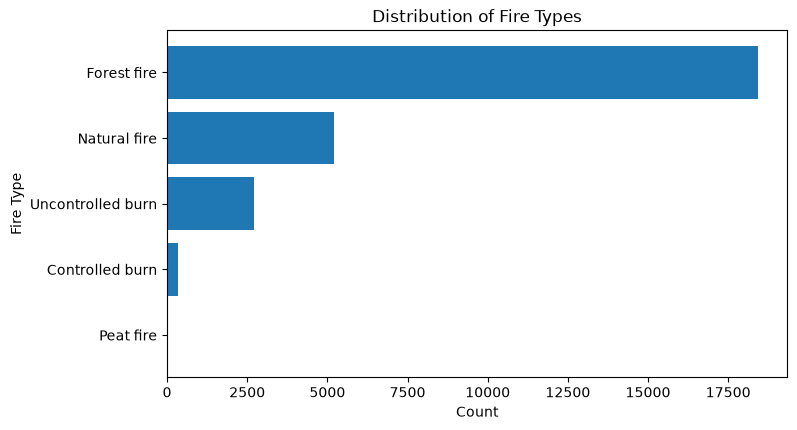

In [21]:
counts = df["type_name"].value_counts(sort=True)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(counts["type_name"], counts["count"])
ax.set_title("Distribution of Fire Types")
ax.set_xlabel("Count")
ax.set_ylabel("Fire Type")
ax.invert_yaxis()

ax

Text(0, 0.5, 'Frequency')

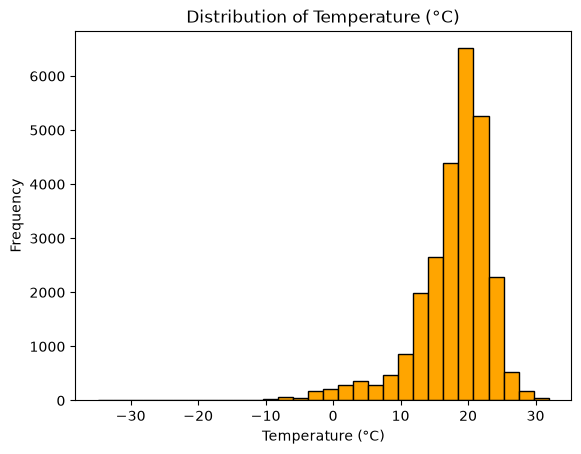

In [22]:
plt.hist(df["temperature_c"], bins=30, color="orange", edgecolor="black")
plt.title("Distribution of Temperature (°C)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

Text(0, 0.5, 'Relative Humidity (%)')

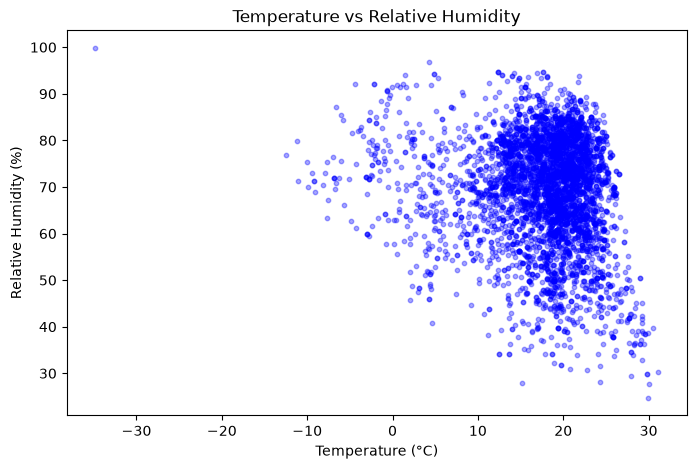

In [23]:
sample = df.sample(n=5000, seed=42)
plt.figure(figsize=(8, 5))
plt.scatter(sample["temperature_c"], sample["relative_humidity"], s=10, alpha=0.35, color="blue")
plt.title("Temperature vs Relative Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")

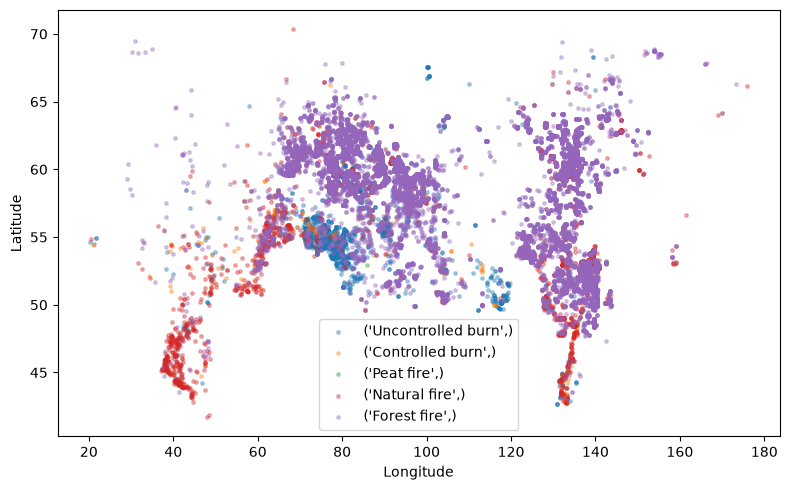

In [24]:
plt.figure(figsize=(8, 5))
for name, group in df.group_by("type_name"):
    plt.scatter(group["lon"], group["lat"], s=6, alpha=0.35, label=name)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.legend()

In [25]:
output_dir = Path(".").parent / "data" / "1"
output_dir.mkdir(parents=True, exist_ok=True)

methods = [
    (pl.DataFrame.write_csv, "optimized_fires.csv", pl.read_csv),
    (pl.DataFrame.write_parquet, "optimized_fires.parquet", pl.read_parquet),
    (pl.DataFrame.write_json, "optimized_fires.json", pl.read_json)
]

for method, filename, reader in methods:
    method(optimized_df, output_dir / filename)
    print(f"{filename=} {(output_dir / filename).stat().st_size / (1024 ** 2):.2f} MiB")
    print(f"{reader(output_dir / filename).shape=}")



filename='optimized_fires.csv' 1.72 MiB
reader(output_dir / filename).shape=(26681, 11)
filename='optimized_fires.parquet' 0.41 MiB
reader(output_dir / filename).shape=(26681, 11)
filename='optimized_fires.json' 5.81 MiB
reader(output_dir / filename).shape=(26681, 11)


# My own analysis on Students Performance in Exams

Датасет взят с [kaggle](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)

Показывает оценки студентов в зависимости от многих показателей

Размер 1000х8

Признаки

1. gender - пол 
2. race/ethnicity - расовое происхождение
3. parental level of education	- уровень образования родителей
4. lunch - еда
5. test preparation course - подготовка к тесту	
6. math score - результат по математике
7. reading score - результат по чтению
8. writing score - результат по письменной части

In [26]:
df = pl.read_csv("data/StudentsPerformance.xls")

df.head()

gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
str,str,str,str,str,i64,i64,i64
"""female""","""group B""","""bachelor's degree""","""standard""","""none""",72,72,74
"""female""","""group C""","""some college""","""standard""","""completed""",69,90,88
"""female""","""group B""","""master's degree""","""standard""","""none""",90,95,93
"""male""","""group A""","""associate's degree""","""free/reduced""","""none""",47,57,44
"""male""","""group C""","""some college""","""standard""","""none""",76,78,75


In [27]:
df.describe()

statistic,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
str,str,str,str,str,str,f64,f64,f64
"""count""","""1000""","""1000""","""1000""","""1000""","""1000""",1000.0,1000.0,1000.0
"""null_count""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0
"""mean""",null,null,null,null,null,66.089,69.169,68.054
"""std""",null,null,null,null,null,15.16308,14.600192,15.195657
"""min""","""female""","""group A""","""associate's degree""","""free/reduced""","""completed""",0.0,17.0,10.0
"""25%""",null,null,null,null,null,57.0,59.0,58.0
"""50%""",null,null,null,null,null,66.0,70.0,69.0
"""75%""",null,null,null,null,null,77.0,79.0,79.0
"""max""","""male""","""group E""","""some high school""","""standard""","""none""",100.0,100.0,100.0


In [28]:
df.glimpse()

Rows: 1000
Columns: 8
$ gender                      <str> 'female', 'female', 'female', 'male', 'male', 'female', 'female', 'male', 'male', 'female'
$ race/ethnicity              <str> 'group B', 'group C', 'group B', 'group A', 'group C', 'group B', 'group B', 'group B', 'group D', 'group B'
$ parental level of education <str> "bachelor's degree", 'some college', "master's degree", "associate's degree", 'some college', "associate's degree", 'some college', 'some college', 'high school', 'high school'
$ lunch                       <str> 'standard', 'standard', 'standard', 'free/reduced', 'standard', 'standard', 'standard', 'free/reduced', 'free/reduced', 'free/reduced'
$ test preparation course     <str> 'none', 'completed', 'none', 'none', 'none', 'none', 'completed', 'none', 'completed', 'none'
$ math score                  <i64> 72, 69, 90, 47, 76, 71, 88, 40, 64, 38
$ reading score               <i64> 72, 90, 95, 57, 78, 83, 95, 43, 64, 60
$ writing score               <i64> 74, 88

In [29]:
df.is_duplicated().sum()

0

In [30]:
df.with_columns(pl.all().is_null()).sum()

gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0


In [31]:
df.with_columns(pl.all().n_unique())[0]

gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
u32,u32,u32,u32,u32,u32,u32,u32
2,5,6,2,2,81,72,77


No nulls and duplicates present in the data

In [32]:
df.glimpse()

Rows: 1000
Columns: 8
$ gender                      <str> 'female', 'female', 'female', 'male', 'male', 'female', 'female', 'male', 'male', 'female'
$ race/ethnicity              <str> 'group B', 'group C', 'group B', 'group A', 'group C', 'group B', 'group B', 'group B', 'group D', 'group B'
$ parental level of education <str> "bachelor's degree", 'some college', "master's degree", "associate's degree", 'some college', "associate's degree", 'some college', 'some college', 'high school', 'high school'
$ lunch                       <str> 'standard', 'standard', 'standard', 'free/reduced', 'standard', 'standard', 'standard', 'free/reduced', 'free/reduced', 'free/reduced'
$ test preparation course     <str> 'none', 'completed', 'none', 'none', 'none', 'none', 'completed', 'none', 'completed', 'none'
$ math score                  <i64> 72, 69, 90, 47, 76, 71, 88, 40, 64, 38
$ reading score               <i64> 72, 90, 95, 57, 78, 83, 95, 43, 64, 60
$ writing score               <i64> 74, 88

In [33]:
# All columns can be optimized
optimized_df = df.with_columns(
    pl.col('gender').cast(pl.Categorical),
    pl.col('race/ethnicity').cast(pl.Categorical),
    pl.col('parental level of education').cast(pl.Categorical),
    pl.col('lunch').cast(pl.Categorical),
    pl.col('test preparation course').cast(pl.Categorical),
    pl.col('math score').cast(pl.Int8),
    pl.col('reading score').cast(pl.Int8),
    pl.col('writing score').cast(pl.Int8),
)

optimized_df.head()

gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
cat,cat,cat,cat,cat,i8,i8,i8
"""female""","""group B""","""bachelor's degree""","""standard""","""none""",72,72,74
"""female""","""group C""","""some college""","""standard""","""completed""",69,90,88
"""female""","""group B""","""master's degree""","""standard""","""none""",90,95,93
"""male""","""group A""","""associate's degree""","""free/reduced""","""none""",47,57,44
"""male""","""group C""","""some college""","""standard""","""none""",76,78,75


In [34]:
df.estimated_size('kb'), optimized_df.estimated_size('kb')

(64.3212890625, 22.4609375)

In [35]:
profit = 100 * (df.estimated_size('kb') - optimized_df.estimated_size('kb')) / df.estimated_size('kb')
print(f"Memory usage reduction: {profit:.2f}%")

Memory usage reduction: 65.08%


Создадим признак среднего гармонического балла по трем предметам

In [36]:
n = len(optimized_df.select(pl.col("^.* score$")).columns)
optimized_df.with_columns(
    (n / pl.sum_horizontal(1 / pl.col("^.* score$"))).alias("harmonic_score").round(2)
)

gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,harmonic_score
cat,cat,cat,cat,cat,i8,i8,i8,f64
"""female""","""group B""","""bachelor's degree""","""standard""","""none""",72,72,74,72.65
"""female""","""group C""","""some college""","""standard""","""completed""",69,90,88,81.15
"""female""","""group B""","""master's degree""","""standard""","""none""",90,95,93,92.62
"""male""","""group A""","""associate's degree""","""free/reduced""","""none""",47,57,44,48.74
"""male""","""group C""","""some college""","""standard""","""none""",76,78,75,76.31
…,…,…,…,…,…,…,…,…
"""female""","""group E""","""master's degree""","""standard""","""completed""",88,99,95,93.78
"""male""","""group C""","""high school""","""free/reduced""","""none""",62,55,55,57.15
"""female""","""group C""","""high school""","""free/reduced""","""completed""",59,71,65,64.63


In [37]:
optimized_df.filter(
    pl.col("test preparation course").eq("none").and_(pl.col("math score") > 90)
).head()

gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
cat,cat,cat,cat,cat,i8,i8,i8
"""male""","""group E""","""some college""","""standard""","""none""",97,87,82
"""male""","""group E""","""some high school""","""standard""","""none""",94,88,78
"""male""","""group E""","""some high school""","""standard""","""none""",92,87,78
"""female""","""group E""","""high school""","""standard""","""none""",99,93,90
"""female""","""group E""","""some college""","""standard""","""none""",100,92,97


In [38]:
optimized_df.group_by("race/ethnicity").agg(
    pl.sum_horizontal(pl.col("^.* score$").cast(pl.Int16)).mean().alias("mean score"),
    pl.sum_horizontal(pl.col("^.* score$").cast(pl.Int16)).std().alias("score std")
).sort(by="race/ethnicity")

race/ethnicity,mean score,score std
cat,f64,f64
"""group A""",188.977528,43.333794
"""group B""",196.405263,44.196399
"""group C""",201.394984,41.616633
"""group D""",207.538168,39.758327
"""group E""",218.257143,43.695047


In [39]:
optimized_df.group_by("parental level of education").agg(
    pl.len().alias("count"),
    pl.sum_horizontal(pl.col("^.* score$").cast(pl.Int16)).max().alias("max score")
)

parental level of education,count,max score
cat,u32,i16
"""high school""",196,287
"""associate's degree""",222,300
"""bachelor's degree""",118,300
"""some college""",226,297
"""some high school""",179,297
"""master's degree""",59,293


In [40]:
optimized_df.select(pl.col("^.* score$").cast(pl.Int16)).corr()

math score,reading score,writing score
f64,f64,f64
1.0,0.81758,0.802642
0.81758,1.0,0.954598
0.802642,0.954598,1.0


In [41]:
optimized_df.select(pl.col("^.* score$").cast(pl.Int16)).describe()

statistic,math score,reading score,writing score
str,f64,f64,f64
"""count""",1000.0,1000.0,1000.0
"""null_count""",0.0,0.0,0.0
"""mean""",66.089,69.169,68.054
"""std""",15.16308,14.600192,15.195657
"""min""",0.0,17.0,10.0
"""25%""",57.0,59.0,58.0
"""50%""",66.0,70.0,69.0
"""75%""",77.0,79.0,79.0
"""max""",100.0,100.0,100.0


(array([  1.,   1.,   0.,   2.,   3.,   7.,   8.,  18.,  36.,  59.,  86.,
        102., 124., 144., 114., 102.,  76.,  59.,  34.,  24.]),
 array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
         55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100.]),
 <BarContainer object of 20 artists>)

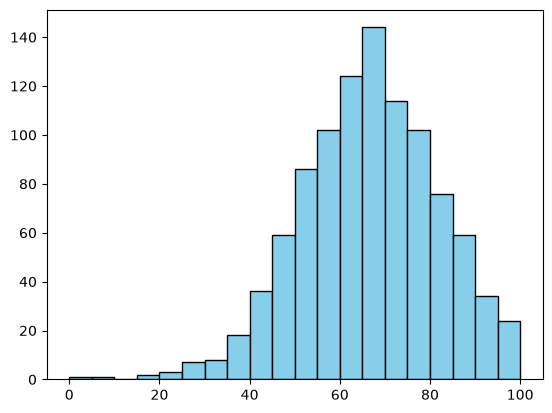

In [42]:
plt.hist(optimized_df["math score"], bins=20, color="skyblue", edgecolor="black")

Видно, что какие-то ученики провалили экзамен, набрав 0 баллов, что может быть как выбросом, так и неудачным результатом

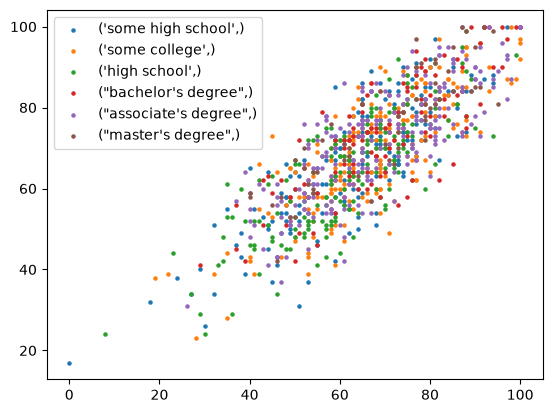

In [43]:
for name, part in df.group_by("parental level of education"):
        plt.scatter(
        part["math score"], part["reading score"],
        s=5, alpha=1, label=name
    )

plt.legend()

Text(0.5, 1.0, 'Race/Ethnicity vs Parental Level of Education')

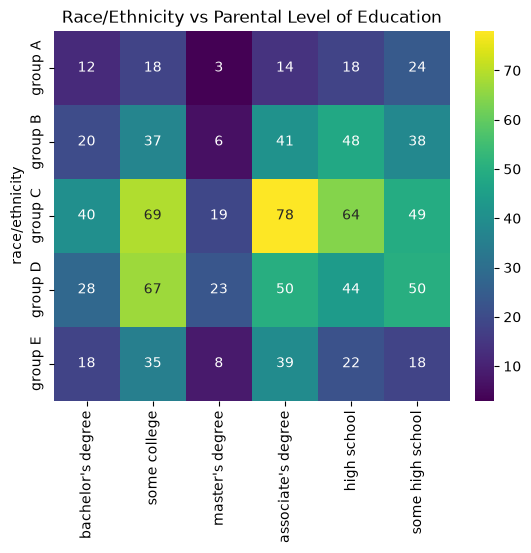

In [44]:
pivot = optimized_df.pivot(
    values="race/ethnicity",
    index="race/ethnicity",
    on="parental level of education",
    aggregate_function="len",
).sort(by="race/ethnicity")

pivot_pd = pivot.to_pandas().set_index("race/ethnicity")
sns.heatmap(pivot_pd, annot=True, fmt="d", cmap="viridis")
plt.title("Race/Ethnicity vs Parental Level of Education")

Text(0, 0.5, 'Reading Score')

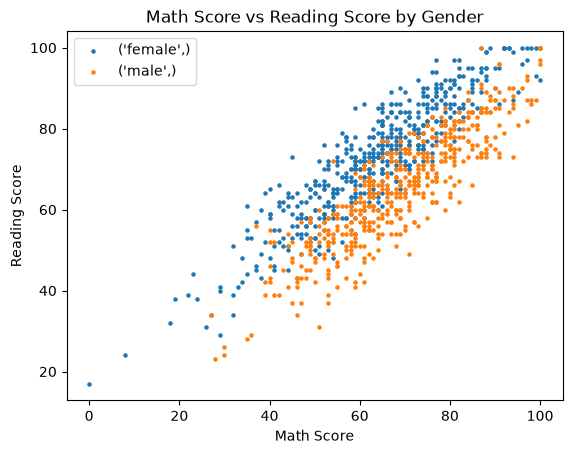

In [45]:
for name, part in df.group_by("gender"):
        plt.scatter(
        part["math score"], part["reading score"],
        s=5, alpha=1, label=name
    )

plt.legend()
plt.title("Math Score vs Reading Score by Gender")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")

# Выводы

Выбранный датасет оказался качественным: не содержал пропусков и дубликатов.

Проведенный анализ показал следующие закономерности:
1. В среднем ученики получают похожие оценки по разным дисциплинам. Это связано с общим уровнем подготовки
2. Мужчины в среднем лучше справляются с математикой, но хуже с чтением относительно девушек
3. В датасете представлены 5 разных этничностей, и можно увидеть, что некоторые этничности вероятнее имеют высшее образование
4. Средний балл учеников зависит от их этничности. АБ тест не проводился для анализа значительности
5. Среднее отклонение балла зависит от этничности


Представленные анализ имеет ограничения:
1. Установленные корреляции никак не связаны с причинностью, но позволяют подсветить существующие проблемы
2. Полученное распределение данных может не отражать реальную картину из-за особенностей конкретно этого сбора данных

In [46]:
output_dir = Path(".").parent / "data" / "1"
output_dir.mkdir(parents=True, exist_ok=True)

methods = [
    (pl.DataFrame.write_csv, "optimized_students.csv", pl.read_csv),
    (pl.DataFrame.write_parquet, "optimized_students.parquet", pl.read_parquet),
    (pl.DataFrame.write_json, "optimized_students.json", pl.read_json)
]

for method, filename, reader in methods:
    method(optimized_df, output_dir / filename)
    print(f"{filename=} {(output_dir / filename).stat().st_size / (1024 ** 2):.2f} MiB")
    print(f"{reader(output_dir / filename).shape=}")



filename='optimized_students.csv' 0.05 MiB
reader(output_dir / filename).shape=(1000, 8)
filename='optimized_students.parquet' 0.01 MiB
reader(output_dir / filename).shape=(1000, 8)
filename='optimized_students.json' 0.19 MiB
reader(output_dir / filename).shape=(1000, 8)
